In [183]:
import numpy as np
import matplotlib.pyplot as plt
import math

i can write the bayes theorem as:
$$
    P(\vec{s}\ |\ p_A) = \frac{P(p_A \ | \ \vec{s})} {P(\vec{s})}
$$
the likelihood is bernoulli distribution:
$$
    P(p_A \ | \ \vec{s}) = p_A^{F_A} (1-p_A)^{F_B}
$$
while the evidence is a $\beta$ distribution:
$$
    P(\vec{s}) = \frac{F_A! \ F_B!}{(F_A + F_B + 1)!}
$$

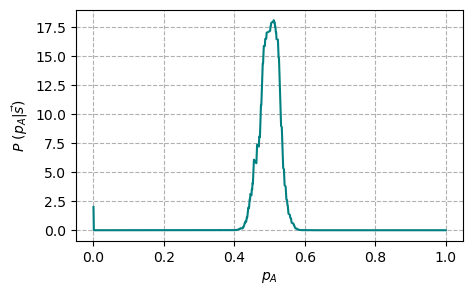

In [495]:
F = 1000 #number of tosses
pA = 0.5 #probability of head
pB = 1 - pA #probability of tail

s = np.random.choice(2, F, p=[pB, pA]).astype(int) #s vector
FAlist = np.zeros(F).astype(int)
FBlist = np.zeros(F).astype(int)

for i, j in zip(range(F-1), s):
    if j == 0:
        FAlist[i] = FAlist[i] 
        FAlist[i+1] = FAlist[i]
        FBlist[i] = FBlist[i] + 1 
        FBlist[i+1] = FBlist[i]
    else:
        FAlist[i] = FAlist[i] + 1
        FAlist[i+1] = FAlist[i]
        FBlist[i] = FBlist[i] 
        FBlist[i+1] = FBlist[i]

def likelihood(pA):
    return (pA**FA) * ((1-pA)**FB) 

pAarray = np.linspace(0.00001, 0.999999, F)
posterior = np.zeros(len(pAarray))
evidence = np.zeros(len(pAarray))

for i, FA, FB in zip(range(F-1), FAlist, FBlist):
    evidence[i] = (math.factorial(FA) * math.factorial(FB)) / (math.factorial(FA + FB + 1))
    posterior[i] = likelihood(pAarray[i]) / evidence[i] 

fig = plt.figure(figsize=(5, 3))
plt.plot(pAarray, posterior, color='teal')
plt.xlabel(r'$p_A$')
plt.ylabel(r'$P\ (p_A|\vec{s})$')
plt.grid(linestyle='dashed')

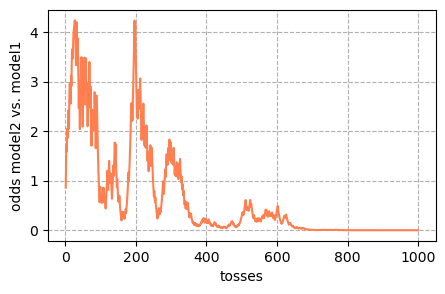

In [498]:
odds = np.zeros(len(pAarray))
tosses = np.linspace(1, F, F)
p0 = 0.57

for i, FA, FB in zip(range(F-1), FAlist, FBlist):
    likModel1 = (math.factorial(FA) * math.factorial(FB)) / (math.factorial(FA + FB + 1))
    likModel2 = (p0**FA) * (1-p0)**FB
    odds[i] = likModel2 / likModel1

fig = plt.figure(figsize=(5, 3))
plt.plot(tosses, odds, color='coral')
plt.xlabel('tosses')
plt.ylabel('odds model2 vs. model1')
plt.grid(linestyle='dashed')